# Dynamic Time Warping

Dynamic Time Warping (DTW) is a method used to measure the similarity between two time series. The basic idea behind DTW is to find an optimal alignment between two time series by warping one of them in the time domain. The warping process is done in a way that minimizes the distance between the two time series.

DTW works by computing a distance matrix that measures the distance between each point in the two sequences. The distance matrix is typically computed using the Euclidean distance or some other distance metric. Once the distance matrix is computed, the DTW algorithm finds the optimal path through the matrix that minimizes the total distance between the two sequences. This path represents the optimal alignment between the two time series. To gain a better intuition of how DTW works, lets consider the folowing time series:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import cdist
from tslearn.metrics import dtw_path

sns.set_theme()

c:\Users\aleja\Python\time_series_clustering\.venv\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


In [2]:
fs = 100
time = np.arange(0, 1, 1/fs)
sinusoid = np.sin(2*np.pi*2*time)

x = np.concatenate((np.zeros(20), sinusoid, np.zeros(50)))
y = np.concatenate((np.zeros(50), sinusoid, np.zeros(20)))
t = np.arange(0, len(x)/fs, 1/fs)

In [3]:
distance_matrix = cdist(x.reshape(len(x), -1), y.reshape(len(y), -1))
path, dist = dtw_path(x, y)

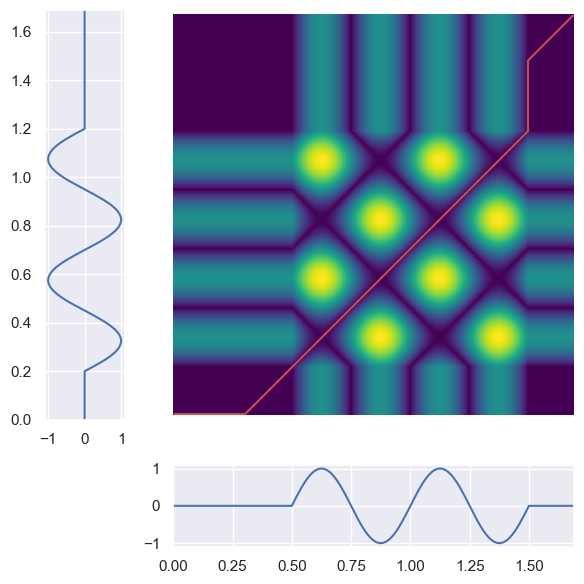

In [15]:
fig, ax = plt.subplots(2, 2, figsize=(6, 6), gridspec_kw={'width_ratios': [1, 5], 'height_ratios': [5, 1]})

ax[0, 1].imshow(distance_matrix, origin='lower', cmap='viridis')
ax[0, 1].plot([j for (i, j) in path], [i for (i, j) in path], color='r')

ax[0, 0].plot(x, t)
ax[1, 1].plot(t, y)
ax[1, 1].set_xlim([0, t[-1]])
ax[0, 0].set_ylim([0, t[-1]])

ax[0, 1].grid(False)

ax[1, 0].axis('off')
ax[0, 1].axis('off')

plt.tight_layout()
plt.show()

Given two time series sequences $x = (x_0, \dots, x_{n-1})$ and $y = (y_0, \dots, y_{n-1})$, DTW can be written formally as follows:





where $a_i$ and $b_j$ are the values of the sequences at time indices $i$ and $j$, respectively, DTW finds the optimal path $\pi$ through a distance matrix $D$, where $D_{i,j}$ is the distance between $a_i$ and $b_j$. The optimal path $\pi$ is defined as:


$$π=arg⁡min⁡π′∑(i,j)∈π′Di,j$$
$$π=argπ′min​(i,j)∈π′∑​Di,j​$$

subject to the following constraints:

    The path starts at $(1,1)$: $\pi_1 = (1,1)$
    The path ends at $(N,M)$: $\pi_{|\pi|} = (N,M)$
    The path moves only in allowed directions: $\pi_{k+1} - \pi_k \in {(1,0), (0,1), (1,1)}$ for $k=1,\dots,|\pi|-1$
    The path is monotonically increasing: $\pi_k \leq \pi_{k+1}$ for $k=1,\dots,|\pi|-1$



Given two time series, $X = (x_1, x_2, ..., x_n)$ and $Y = (y_1, y_2, ..., y_m)$, we can define a cost matrix $C$ as:

$$C(i,j) = d(x_i, y_j)$$

where $d(x_i, y_j)$ is a distance function between $x_i$ and $y_j$.

We can then define a path $P$ as a sequence of indices $(p_1, p_2, ..., p_K)$ where $p_k = (i_k, j_k)$ and $1 \leq i_k \leq n$ and $1 \leq j_k \leq m$.

The cost of a path $P$ is defined as:

$$cost(P) = \sum_{k=1}^{K} C(p_k)$$

The objective of DTW is to find the path $P$ that minimizes the cost function:

$$DTW(X,Y) = \min_{P} cost(P)$$

subject to the following constraints:

- Boundary conditions: $p_1 = (1,1)$ and $p_K = (n,m)$.
- Continuity: adjacent points in the path are close to each other, i.e., $|i_k - i_{k-1}| \leq 1$ and $|j_k - j_{k-1}| \leq 1$.
- Monotonicity: the path moves forward in time, i.e., $i_k \leq i_{k+1}$ and $j_k \leq j_{k+1}$.

Once the optimal path $P$ has been found, the DTW distance between the two time series can be computed as the cost of the path:

$$DTW(X,Y) = cost(P^*)$$

where $P^*$ is the optimal path.

c:\Users\aleja\Python\time_series_clustering\.venv\lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)
C:\Users\aleja\AppData\Local\Temp\ipykernel_12340\618592589.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


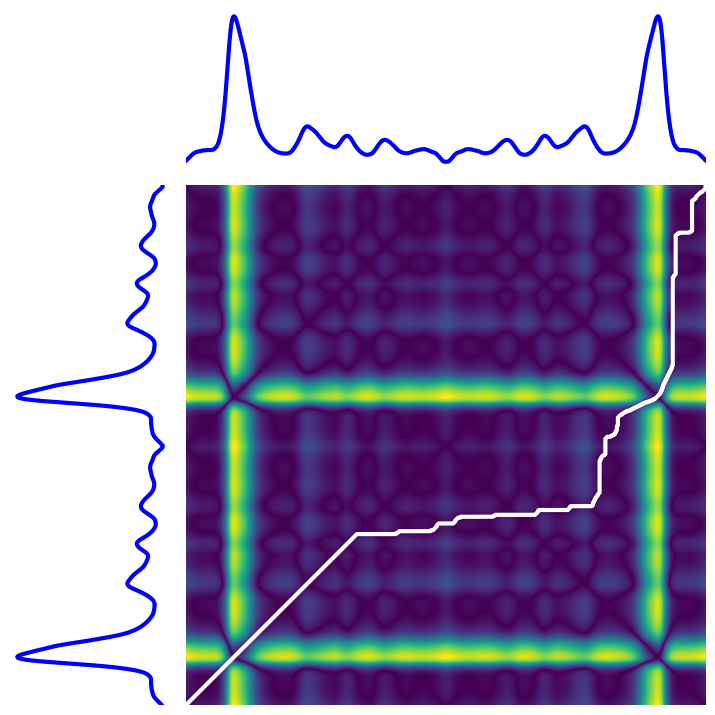

In [1]:
# Author: Romain Tavenard
# License: BSD 3 clause

import numpy
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt

from tslearn import metrics

numpy.random.seed(0)

s_x = numpy.array(
    [-0.790, -0.765, -0.734, -0.700, -0.668, -0.639, -0.612, -0.587, -0.564,
     -0.544, -0.529, -0.518, -0.509, -0.502, -0.494, -0.488, -0.482, -0.475,
     -0.472, -0.470, -0.465, -0.464, -0.461, -0.458, -0.459, -0.460, -0.459,
     -0.458, -0.448, -0.431, -0.408, -0.375, -0.333, -0.277, -0.196, -0.090,
     0.047, 0.220, 0.426, 0.671, 0.962, 1.300, 1.683, 2.096, 2.510, 2.895,
     3.219, 3.463, 3.621, 3.700, 3.713, 3.677, 3.606, 3.510, 3.400, 3.280,
     3.158, 3.038, 2.919, 2.801, 2.676, 2.538, 2.382, 2.206, 2.016, 1.821,
     1.627, 1.439, 1.260, 1.085, 0.917, 0.758, 0.608, 0.476, 0.361, 0.259,
     0.173, 0.096, 0.027, -0.032, -0.087, -0.137, -0.179, -0.221, -0.260,
     -0.293, -0.328, -0.359, -0.385, -0.413, -0.437, -0.458, -0.480, -0.498,
     -0.512, -0.526, -0.536, -0.544, -0.552, -0.556, -0.561, -0.565, -0.568,
     -0.570, -0.570, -0.566, -0.560, -0.549, -0.532, -0.510, -0.480, -0.443,
     -0.402, -0.357, -0.308, -0.256, -0.200, -0.139, -0.073, -0.003, 0.066,
     0.131, 0.186, 0.229, 0.259, 0.276, 0.280, 0.272, 0.256, 0.234, 0.209,
     0.186, 0.162, 0.139, 0.112, 0.081, 0.046, 0.008, -0.032, -0.071, -0.110,
     -0.147, -0.180, -0.210, -0.235, -0.256, -0.275, -0.292, -0.307, -0.320,
     -0.332, -0.344, -0.355, -0.363, -0.367, -0.364, -0.351, -0.330, -0.299,
     -0.260, -0.217, -0.172, -0.128, -0.091, -0.060, -0.036, -0.022, -0.016,
     -0.020, -0.037, -0.065, -0.104, -0.151, -0.201, -0.253, -0.302, -0.347,
     -0.388, -0.426, -0.460, -0.491, -0.517, -0.539, -0.558, -0.575, -0.588,
     -0.600, -0.606, -0.607, -0.604, -0.598, -0.589, -0.577, -0.558, -0.531,
     -0.496, -0.454, -0.410, -0.364, -0.318, -0.276, -0.237, -0.203, -0.176,
     -0.157, -0.145, -0.142, -0.145, -0.154, -0.168, -0.185, -0.206, -0.230,
     -0.256, -0.286, -0.318, -0.351, -0.383, -0.414, -0.442, -0.467, -0.489,
     -0.508, -0.523, -0.535, -0.544, -0.552, -0.557, -0.560, -0.560, -0.557,
     -0.551, -0.542, -0.531, -0.519, -0.507, -0.494, -0.484, -0.476, -0.469,
     -0.463, -0.456, -0.449, -0.442, -0.435, -0.431, -0.429, -0.430, -0.435,
     -0.442, -0.452, -0.465, -0.479, -0.493, -0.506, -0.517, -0.526, -0.535,
     -0.548, -0.567, -0.592, -0.622, -0.655, -0.690, -0.728, -0.764, -0.795,
     -0.815, -0.823, -0.821])

s_y1 = numpy.concatenate((s_x, s_x)).reshape((-1, 1))
s_y2 = numpy.concatenate((s_x, s_x[::-1])).reshape((-1, 1))
sz = s_y1.shape[0]

path, sim = metrics.dtw_path(s_y1, s_y2)

plt.figure(1, figsize=(8, 8))

# definitions for the axes
left, bottom = 0.01, 0.1
w_ts = h_ts = 0.2
left_h = left + w_ts + 0.02
width = height = 0.65
bottom_h = bottom + height + 0.02

rect_s_y = [left, bottom, w_ts, height]
rect_gram = [left_h, bottom, width, height]
rect_s_x = [left_h, bottom_h, width, h_ts]

ax_gram = plt.axes(rect_gram)
ax_s_x = plt.axes(rect_s_x)
ax_s_y = plt.axes(rect_s_y)

mat = cdist(s_y1, s_y2)

ax_gram.imshow(mat, origin='lower')
ax_gram.axis("off")
ax_gram.autoscale(False)
ax_gram.plot([j for (i, j) in path], [i for (i, j) in path], "w-",
             linewidth=3.)

ax_s_x.plot(numpy.arange(sz), s_y2, "b-", linewidth=3.)
ax_s_x.axis("off")
ax_s_x.set_xlim((0, sz - 1))

ax_s_y.plot(- s_y1, numpy.arange(sz), "b-", linewidth=3.)
ax_s_y.axis("off")
ax_s_y.set_ylim((0, sz - 1))

plt.tight_layout()
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [5]:
def dtw_distance(x, y, dist_func):
    """
    Computes the dynamic time warping distance between two sequences x and y.
    
    Parameters:
    -----------
    x : array-like
        A 1-D sequence.
    y : array-like
        A 1-D sequence.
    dist_func : function
        A function that computes the distance between two points.
    
    Returns:
    --------
    float
        The dynamic time warping distance between x and y.
    """
    n = len(x)
    m = len(y)
    D = np.zeros((n+1, m+1))
    D[0,1:] = np.inf
    D[1:,0] = np.inf
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = dist_func(x[i-1], y[j-1])
            D[i,j] = cost + min(D[i-1,j], D[i,j-1], D[i-1,j-1])
    return D[n,m]

In [2]:
fs = 1000
t = np.arange(0, 1, 1/fs)

X = np.sin(2*np.pi*1*t)
Y = np.sin(2*np.pi*1*t + np.pi/3)


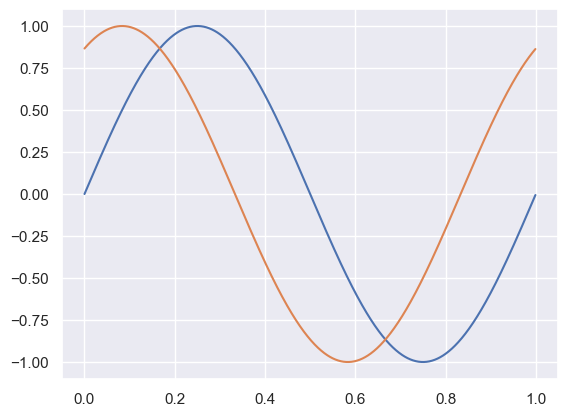

In [4]:
plt.plot(t, X)
plt.plot(t, Y)
plt.show()

In [11]:
def euclidean_dist(x, y):
    return np.linalg.norm(x - y)


def euclidean_distance(x, y):
    return np.sqrt(np.sum((x-y)**2))

def manhattan_distance(x, y):
    return np.sum(np.abs(x-y))

def cosine_distance(x, y):
    return 1 - np.dot(x, y) / (np.linalg.norm(x) * np.linalg.norm(y))

def pearson_distance(x, y):
    return 1 - np.corrcoef(x, y)[0,1]

def hamming_distance(x, y):
    return np.sum(x != y)


146.42941559519826

In [ ]:
dtw_distance(X, Y, euclidean_dist)